# 6-Robot det(J) Saddle Navigator

Pentagon-plus-center formation (5 ring + 1 center robot) fits a **quadratic model** to both
components of a planar vector field, uses **closed-form polynomial formulas** to extract the
gradient and Hessian of det(J), and drives the centroid to a saddle of det(J) using the
**AdaptiveEigenStepper** (Logic 5 from `saddle_point_6_robot2.ipynb`).

det(J) is a scalar invariant of the Jacobian, so the same stepper that navigates a scalar-field
saddle works here without modification.

**Valid field types:** `'double_vortex'`, `'double_saddle'`, `'double_gyre'`, `'four_vortex'`,
`'double_vortex_gauss'`, `'double_vortex_log'`, `'four_vortex_gauss'`, `'four_vortex_log'`

In [161]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Vector field

In [162]:
class VectorField:
    """Eight field types: 'double_vortex', 'double_saddle', 'double_gyre', 'four_vortex',
    'double_vortex_gauss', 'double_vortex_log', 'four_vortex_gauss', 'four_vortex_log'."""

    def __init__(self, field_type='double_vortex',
                 dg_A=0.1, dg_eps=0.0, dg_omega=2*np.pi/10, dg_t=0.0):
        self.field_type = field_type
        self.vortex1_pos = np.array([-2, -1])
        self.vortex2_pos = np.array([2, -1])
        self.saddle1_pos = np.array([3, 3])
        self.saddle2_pos = np.array([-3, -3])
        # four_vortex (legacy): upper pair CCW (+1), lower pair CW (-1). Weighted average
        # with fv_eps softening so the trench between pairs dominates over core spikes.
        self.fv_centers = np.array([[-1, 1], [1, 1], [-1, -1], [1, -1]], dtype=float)
        self.fv_signs   = [1, -1, 1, -1]
        self.fv_eps     = 0.25
        self.fv_gain    = 5.0
        self.dg_A = dg_A
        self.dg_eps = dg_eps
        self.dg_omega = dg_omega
        self.dg_t = dg_t
        # Hamiltonian streamfunction vortex fields.
        # psi(x, y) = sum_i s_i * phi(r_i^2)
        # u = -d psi/dy, v = d psi/dx  -- incompressible by construction.
        # phi = Gaussian for *_gauss,  phi = (1/2)*log(r^2 + eps) for *_log.
        self.dvham_centers = np.array([[-1, 0], [1, 0]], dtype=float)
        self.dvham_signs   = np.array([1, -1], dtype=float)
        self.fvham_centers = np.array([[-1, 1], [1, 1], [-1, -1], [1, -1]], dtype=float)
        # Checkerboard sign pattern: (+,-,-,+) gives a true det(J) saddle at the origin
        # with four corner peaks. Row-symmetric (+,+,-,-) was wrong: it put a local max
        # of det(J) at the origin and placed the real saddles far out at (~1.8, ~1.6).
        self.fvham_signs   = np.array([1, -1, -1, 1], dtype=float)
        self.ham_sigma = 0.7   # Gaussian width
        self.ham_eps   = 0.25  # log softening
        self.ham_gain  = 1.0

    def evaluate(self, x, y):
        if self.field_type == 'double_vortex':
            x1, y1 = self.vortex1_pos
            vx1 = -(y - y1); vy1 = (x - x1)
            x2, y2 = self.vortex2_pos
            vx2 =  (y - y2); vy2 = -(x - x2)
            d1 = np.sqrt((x - x1)**2 + (y - y1)**2)
            d2 = np.sqrt((x - x2)**2 + (y - y2)**2)
            w1 = 1.0 / (d1**2 + 0.1)
            w2 = 1.0 / (d2**2 + 0.1)
            vx = (vx1 * w1 + vx2 * w2) / (w1 + w2)
            vy = (vy1 * w1 + vy2 * w2) / (w1 + w2)
            return np.array([10*vx, 10*vy])

        elif self.field_type == 'double_saddle':
            s1 = self.saddle1_pos; s2 = self.saddle2_pos
            rot1, rot2 = np.pi/4, -np.pi/4

            x1c = x - s1[0]; y1c = y - s1[1]
            c1, si1 = np.cos(rot1), np.sin(rot1)
            x1r = c1*x1c - si1*y1c; y1r = si1*x1c + c1*y1c
            u1r =  x1r; v1r = -y1r
            u1 =  c1*u1r + si1*v1r
            v1 = -si1*u1r +  c1*v1r

            x2c = x - s2[0]; y2c = y - s2[1]
            c2, si2 = np.cos(rot2), np.sin(rot2)
            x2r = c2*x2c - si2*y2c; y2r = si2*x2c + c2*y2c
            u2r =  x2r; v2r = -y2r
            u2 =  c2*u2r + si2*v2r
            v2 = -si2*u2r +  c2*v2r

            d1 = np.sqrt((x - s1[0])**2 + (y - s1[1])**2) + 0.01
            d2 = np.sqrt((x - s2[0])**2 + (y - s2[1])**2) + 0.01
            w1 = 1.0 / (d1**2); w2 = 1.0 / (d2**2)
            tw = w1 + w2
            return np.array([(u1*w1 + u2*w2)/tw, (v1*w1 + v2*w2)/tw])

        elif self.field_type == 'double_gyre':
            A = self.dg_A; eps = self.dg_eps
            omega = self.dg_omega; t = self.dg_t
            f  = eps * np.sin(omega*t) * x**2 + (1 - 2*eps*np.sin(omega*t)) * x
            df = 2*eps * np.sin(omega*t) * x + (1 - 2*eps*np.sin(omega*t))
            u = -np.pi * A * np.sin(np.pi*f) * np.cos(np.pi*y)
            v =  np.pi * A * np.cos(np.pi*f) * np.sin(np.pi*y) * df
            return np.array([u, v])

        elif self.field_type == 'four_vortex':
            # Weighted average of four point vortices. Upper pair CCW, lower pair CW.
            # Separatrix at y=0 (and x=0); central saddle of det(J) at (0, 0).
            vx_arr, vy_arr, w_arr = [], [], []
            for (cx, cy), s in zip(self.fv_centers, self.fv_signs):
                dx, dy = x - cx, y - cy
                r2 = dx**2 + dy**2
                w = 1.0 / (r2 + self.fv_eps)
                vx_arr.append(-s * dy / (r2 + self.fv_eps))
                vy_arr.append( s * dx / (r2 + self.fv_eps))
                w_arr.append(w)
            W = sum(w_arr)
            vx = sum(wi * vxi for wi, vxi in zip(w_arr, vx_arr)) / W
            vy = sum(wi * vyi for wi, vyi in zip(w_arr, vy_arr)) / W
            return np.array([self.fv_gain * vx, self.fv_gain * vy])

        elif self.field_type == 'four_vortex_gauss':
            psi_x, psi_y = 0.0, 0.0
            s2 = self.ham_sigma ** 2
            for (cx, cy), s in zip(self.fvham_centers, self.fvham_signs):
                dx, dy = x - cx, y - cy
                g = np.exp(-(dx*dx + dy*dy) / (2*s2))
                psi_x += s * (-dx / s2) * g
                psi_y += s * (-dy / s2) * g
            return np.array([self.ham_gain * (-psi_y), self.ham_gain * psi_x])

        elif self.field_type == 'four_vortex_log':
            psi_x, psi_y = 0.0, 0.0
            for (cx, cy), s in zip(self.fvham_centers, self.fvham_signs):
                dx, dy = x - cx, y - cy
                denom = dx*dx + dy*dy + self.ham_eps
                psi_x += s * dx / denom
                psi_y += s * dy / denom
            return np.array([self.ham_gain * (-psi_y), self.ham_gain * psi_x])

        elif self.field_type == 'double_vortex_gauss':
            psi_x, psi_y = 0.0, 0.0
            s2 = self.ham_sigma ** 2
            for (cx, cy), s in zip(self.dvham_centers, self.dvham_signs):
                dx, dy = x - cx, y - cy
                g = np.exp(-(dx*dx + dy*dy) / (2*s2))
                psi_x += s * (-dx / s2) * g
                psi_y += s * (-dy / s2) * g
            return np.array([self.ham_gain * (-psi_y), self.ham_gain * psi_x])

        elif self.field_type == 'double_vortex_log':
            psi_x, psi_y = 0.0, 0.0
            for (cx, cy), s in zip(self.dvham_centers, self.dvham_signs):
                dx, dy = x - cx, y - cy
                denom = dx*dx + dy*dy + self.ham_eps
                psi_x += s * dx / denom
                psi_y += s * dy / denom
            return np.array([self.ham_gain * (-psi_y), self.ham_gain * psi_x])

        else:
            raise ValueError(f"Unknown field_type: {self.field_type}")

    def jacobian_twosided(self, x, y, h=0.01):
        fxp, fyp = self.evaluate(x + h, y)
        fxm, fym = self.evaluate(x - h, y)
        fxyp, fyyp = self.evaluate(x, y + h)
        fxym, fyym = self.evaluate(x, y - h)
        return np.array([
            [(fxp - fxm)/(2*h), (fxyp - fxym)/(2*h)],
            [(fyp - fym)/(2*h), (fyyp - fyym)/(2*h)],
        ])

## Pentagon + center formation

5 robots on a pentagon ring + 1 at the center. Fixed orientation (`base_angle=0.0`), square 6x6
Phi matrix. Copied verbatim from `saddle_point_6_robot2.ipynb`.

In [163]:
class PentagonFormation:
    """5 robots on a pentagon ring + 1 at the center."""

    def __init__(self, radius=0.2, base_angle=0.0):
        self.radius = radius
        self.base_angle = base_angle

    def robot_positions(self, centroid):
        centroid = np.asarray(centroid)
        angles = self.base_angle + 2 * np.pi * np.arange(5) / 5
        ring = centroid[None, :] + self.radius * np.column_stack([np.cos(angles), np.sin(angles)])
        return np.vstack([ring, centroid[None, :]])

    def relative_positions(self, centroid):
        return self.robot_positions(centroid) - np.asarray(centroid)[None, :]

## Quadratic estimator + det(J) analytic formulas

Basis `[1, x, y, x^2/2, x*y, y^2/2]`. Solving `Phi @ theta = readings` gives the Taylor data
at the centroid: `theta = [f0, f_x, f_y, f_xx, f_xy, f_yy]`.

Called twice per iteration (once for u, once for v) to get `theta_u` and `theta_v`. Then the
closed-form polynomial formulas for the gradient and Hessian of det(J(r)) at r=0 follow directly
from the six Taylor coefficients.

In [164]:
class QuadraticEstimator:
    """Fit a quadratic model from 6 readings; Hessian falls out of the coefficients."""

    @staticmethod
    def basis(rx, ry):
        return np.array([1, rx, ry, rx**2 / 2, rx * ry, ry**2 / 2], dtype=float)

    def fit(self, relative_positions, readings):
        Phi = np.array([self.basis(r[0], r[1]) for r in relative_positions])
        try:
            theta = np.linalg.solve(Phi, readings)
        except np.linalg.LinAlgError:
            theta = np.linalg.lstsq(Phi, readings, rcond=None)[0]
        return theta

    def extract_gradient(self, theta):
        return theta[1:3]

    def extract_hessian(self, theta):
        return np.array([[theta[3], theta[4]], [theta[4], theta[5]]])

    @staticmethod
    def det_gradient(theta_u, theta_v):
        # Closed-form gradient of det(J(r)) at r=0.
        # Derivation: J entries are affine in r, so det(J) is quadratic.
        # Differentiate D(r) = det(J(r)) and evaluate at r=0.
        _, ux, uy, uxx, uxy, uyy = theta_u
        _, vx, vy, vxx, vxy, vyy = theta_v
        D_x = uxx*vy + ux*vxy - uxy*vx - uy*vxx
        D_y = uxy*vy + ux*vyy - uyy*vx - uy*vxy
        return np.array([D_x, D_y])

    @staticmethod
    def det_hessian(theta_u, theta_v):
        # Closed-form Hessian of det(J(r)); constant because D(r) is quadratic.
        _, _, _, uxx, uxy, uyy = theta_u
        _, _, _, vxx, vxy, vyy = theta_v
        D_xx = 2*uxx*vxy - 2*uxy*vxx
        D_xy = uxx*vyy - uyy*vxx
        D_yy = 2*uxy*vyy - 2*uyy*vxy
        return np.array([[D_xx, D_xy], [D_xy, D_yy]])

    @staticmethod
    def det_value(theta_u, theta_v):
        # D_0 = u_x*v_y - u_y*v_x at the centroid (r=0).
        _, ux, uy, _, _, _ = theta_u
        _, vx, vy, _, _, _ = theta_v
        return ux*vy - uy*vx

## Steppers

### Logic A: AdaptiveEigenStepper (Logic 5 from `saddle_point_6_robot2.ipynb`)

Per-component hyperbolic saturation with the **signed** lambda denominator.

    c_i = -(v_i . grad) / lambda_i,   s_i = v_max * tanh(c_i / v_max)

Both eigen-directions attract toward the saddle of det(J). Snap to trench + converge to saddle.
Far from trench: bounded reach at v_max per eigen-direction.
Near saddle: exact Newton with cubic convergence.

---

### Logic B: AdaptiveEigenStepperAbs (Logic 6 / Dauphin from `saddle_point_6_robot2.ipynb`)

Same structure but with **|lambda|** in the denominator.

    c_i = -(v_i . grad) / |lambda_i|,   s_i = v_max * tanh(c_i / v_max)

Perpendicular direction (lambda > 0): snaps to trench (same as Logic A).
Along-trench direction (lambda < 0): **repels** from saddle, slides down the trench.

---

### Logic C: Hybrid 3-mode stepper

Three modes: FLOW when on the separatrix, A or B when off it.

**FLOW mode trigger** (enter when EITHER condition holds):

- `|det(J)| < EPS_RAW`  (raw threshold, default 1e-3)
- `|det(J)| / ||H_det||_F < EPS_DIM`  (dimensionless, default 0.025)

**FLOW mode step:**

Eigendecompose H_det into (v_neg, lambda_neg) and (v_pos, lambda_pos).
v_neg is tangent to the trench; v_pos is perpendicular.

    f       = (theta_u[0], theta_v[0])        # local flow at centroid
    c_along = f . v_neg                        # flow speed along trench
    r_perp  = (grad_det . v_pos) / lambda_pos  # signed distance off trench
    c_perp  = -r_perp                          # snap correction
    step    = v_max*tanh(c_along/v_max)*v_neg + v_max*tanh(c_perp/v_max)*v_pos

The perpendicular snap keeps the cluster on the trench even when the flow estimate is
noisy (e.g., dg_eps > 0 unsteady gyre). If H_det is degenerate, falls back to a plain
saturated flow step along f.

**Off-trench A/B selector (flow-projected-on-trench):**

Project the local flow f onto v_neg (the along-trench eigenvector of H_det).
v_neg is sign-stabilised so that (v_neg . grad_det) < 0, anchoring it to the
det(J) descent direction and removing numpy's arbitrary eigenvector sign flip.

- `f . v_neg > 0`: flow heads in the descent direction along the trench. Use B.
- else: flow heads toward the saddle. Use A.

`compute_step` returns `(step, mode_label)` where `mode_label in {'FLOW', 'A', 'B', 'flow_fallback'}`.

Earlier drafts also explored a gradient-flow-alignment selector (D) and a trace(J) selector (E);
both failed on incompressible fields (trace = 0 everywhere) and were removed.

In [165]:
class AdaptiveEigenStepper:
    """Logic A: signed lambda denominator. Snaps to trench and converges to saddle.

    s_i = v_max * tanh( (-g_i / lambda_i) / v_max ),  step = sum_i s_i v_i

    Far from trench  -> bounded reach at v_max per eigen-direction.
    Near saddle      -> exact Newton (cubic convergence, no chatter).
    """

    def __init__(self, v_max=0.04):
        self.v_max = v_max

    def compute_step(self, gradient, hessian):
        lam, V = np.linalg.eigh(hessian)
        eps = 1e-9
        if lam[0] * lam[1] >= -eps or np.min(np.abs(lam)) < eps:
            delta = -np.linalg.pinv(hessian) @ gradient
            n = np.linalg.norm(delta)
            if n > 1e-12:
                return delta * (self.v_max * np.tanh(n / self.v_max) / n)
            return delta
        c0 = -(V[:, 0] @ gradient) / lam[0]
        c1 = -(V[:, 1] @ gradient) / lam[1]
        s0 = self.v_max * np.tanh(c0 / self.v_max)
        s1 = self.v_max * np.tanh(c1 / self.v_max)
        return s0 * V[:, 0] + s1 * V[:, 1]


class AdaptiveEigenStepperAbs:
    """Logic B: |lambda| denominator (Dauphin-style). Snaps to trench, then descends along it.

    s_i = v_max * tanh( (-g_i / |lambda_i|) / v_max ),  step = sum_i s_i v_i

    Perp direction (lambda > 0): c_perp ~ -r_perp  -> snap to trench (same as Logic A).
    Along direction (lambda < 0): c_along ~ +r_along -> repel from saddle, slide along trench.
    """

    def __init__(self, v_max=0.04):
        self.v_max = v_max

    def compute_step(self, gradient, hessian):
        lam, V = np.linalg.eigh(hessian)
        eps = 1e-9
        if lam[0] * lam[1] >= -eps or np.min(np.abs(lam)) < eps:
            delta = -np.linalg.pinv(hessian) @ gradient
            n = np.linalg.norm(delta)
            if n > 1e-12:
                return delta * (self.v_max * np.tanh(n / self.v_max) / n)
            return delta
        denom = np.abs(lam)
        c0 = -(V[:, 0] @ gradient) / denom[0]
        c1 = -(V[:, 1] @ gradient) / denom[1]
        s0 = self.v_max * np.tanh(c0 / self.v_max)
        s1 = self.v_max * np.tanh(c1 / self.v_max)
        return s0 * V[:, 0] + s1 * V[:, 1]


# ---------------------------------------------------------------------------
# Logic C: hybrid 3-mode stepper
# ---------------------------------------------------------------------------

class HybridStepperBase:
    """Shared infrastructure for Logic C.

    Provides:
      _is_on_separatrix(det_val, H_det) -> bool
      _flow_step(theta_u, theta_v, grad_det, H_det) -> (step, mode_label)
      _logic_a_step(grad_det, H_det) -> step
      _logic_b_step(grad_det, H_det) -> step

    Subclasses implement compute_step(theta_u, theta_v, grad_det, H_det) -> (step, mode_label).

    Defaults: eps_raw=1e-3, eps_dim=0.025. The dimensionless threshold is the more
    important one -- it catches the separatrix band even when the formation radius
    means det_val is nonzero. Raise eps_dim to widen the FLOW band.
    """

    def __init__(self, v_max=0.04, eps_raw=1e-3, eps_dim=0.025):
        self.v_max = v_max
        self.eps_raw = eps_raw
        self.eps_dim = eps_dim

    def _is_on_separatrix(self, det_val, H_det):
        H_norm = np.linalg.norm(H_det, 'fro')
        on_raw = abs(det_val) < self.eps_raw
        on_dim = (abs(det_val) / max(H_norm, 1e-12)) < self.eps_dim
        return on_raw or on_dim

    def _flow_step(self, theta_u, theta_v, grad_det, H_det):
        """Follow local flow tangent to the trench, with perpendicular snap."""
        f = np.array([theta_u[0], theta_v[0]])
        lam, V = np.linalg.eigh(H_det)
        eps = 1e-9
        if lam[0] * lam[1] >= -eps or np.min(np.abs(lam)) < eps:
            # Degenerate Hessian: plain saturated flow step.
            n = np.linalg.norm(f)
            if n < 1e-12:
                return np.zeros(2), 'flow_fallback'
            return f * (self.v_max * np.tanh(n / self.v_max) / n), 'flow_fallback'
        i_neg = 0 if lam[0] < lam[1] else 1
        i_pos = 1 - i_neg
        v_neg, v_pos = V[:, i_neg], V[:, i_pos]
        # Along-trench: follow the flow.
        c_along = float(f @ v_neg)
        # Perpendicular: snap back to the trench (same formula as Logic A/B).
        r_perp = float(grad_det @ v_pos) / lam[i_pos]
        c_perp = -r_perp
        s_along = self.v_max * np.tanh(c_along / self.v_max)
        s_perp  = self.v_max * np.tanh(c_perp  / self.v_max)
        return s_along * v_neg + s_perp * v_pos, 'FLOW'

    def _logic_a_step(self, grad_det, H_det):
        """Signed lambda denominator (Logic A body)."""
        lam, V = np.linalg.eigh(H_det)
        eps = 1e-9
        if lam[0] * lam[1] >= -eps or np.min(np.abs(lam)) < eps:
            delta = -np.linalg.pinv(H_det) @ grad_det
            n = np.linalg.norm(delta)
            if n > 1e-12:
                return delta * (self.v_max * np.tanh(n / self.v_max) / n)
            return delta
        c0 = -(V[:, 0] @ grad_det) / lam[0]
        c1 = -(V[:, 1] @ grad_det) / lam[1]
        return self.v_max * np.tanh(c0 / self.v_max) * V[:, 0] + \
               self.v_max * np.tanh(c1 / self.v_max) * V[:, 1]

    def _logic_b_step(self, grad_det, H_det):
        """|lambda| denominator (Logic B body)."""
        lam, V = np.linalg.eigh(H_det)
        eps = 1e-9
        if lam[0] * lam[1] >= -eps or np.min(np.abs(lam)) < eps:
            delta = -np.linalg.pinv(H_det) @ grad_det
            n = np.linalg.norm(delta)
            if n > 1e-12:
                return delta * (self.v_max * np.tanh(n / self.v_max) / n)
            return delta
        denom = np.abs(lam)
        c0 = -(V[:, 0] @ grad_det) / denom[0]
        c1 = -(V[:, 1] @ grad_det) / denom[1]
        return self.v_max * np.tanh(c0 / self.v_max) * V[:, 0] + \
               self.v_max * np.tanh(c1 / self.v_max) * V[:, 1]


class LogicCStepper(HybridStepperBase):
    """Logic C: flow-projected-on-trench selector.

    Project local flow f = (theta_u[0], theta_v[0]) onto the along-trench direction.
    The along-trench eigenvector v_neg is sign-stabilised so that (v_neg . grad_det) < 0,
    meaning v_neg points away from the det(J) peak and along the descent direction of the
    trench. This removes the arbitrary sign flip that numpy's eigh can produce.

      (f . v_neg) > 0  ->  flow moves in the descent direction -> Logic B (slide along trench)
      else             ->  flow moves against the descent direction -> Logic A (toward saddle)
    """

    def compute_step(self, theta_u, theta_v, grad_det, H_det):
        det_val = QuadraticEstimator.det_value(theta_u, theta_v)
        if self._is_on_separatrix(det_val, H_det):
            return self._flow_step(theta_u, theta_v, grad_det, H_det)
        lam, V = np.linalg.eigh(H_det)
        eps = 1e-9
        if lam[0] * lam[1] >= -eps:
            return self._logic_a_step(grad_det, H_det), 'A'
        i_neg = 0 if lam[0] < lam[1] else 1
        v_neg = V[:, i_neg]
        # Stabilise sign: ensure v_neg points in the direction where det(J) decreases,
        # i.e. (v_neg . grad_det) < 0. If not, flip it.
        if float(grad_det @ v_neg) > 0:
            v_neg = -v_neg
        f = np.array([theta_u[0], theta_v[0]])
        # f . v_neg > 0 means flow points in the descent direction along the trench.
        if float(f @ v_neg) > 0:
            return self._logic_b_step(grad_det, H_det), 'B'
        return self._logic_a_step(grad_det, H_det), 'A'

## Math cross-check: analytical vs. finite-difference det(J) gradient and Hessian

Verifies the closed-form formulas against numerical finite differences at a fixed test point.
Run this cell any time the estimator formulas are edited.

In [166]:
def _crosscheck_det_formulas(field_type='double_saddle', test_centroid=(0.5, 0.5),
                              formation_radius=0.2, h_fd=0.005):
    """Verify closed-form det(J) gradient and Hessian against finite differences.

    The finite differences are evaluated on the QUADRATIC FIT MODEL (not the true field),
    because det_gradient / det_hessian are derivatives of the local quadratic approximation
    to det(J), not of the true field's det(J). The true field has higher-order terms that
    the 6-robot fit does not capture.
    """
    vf_test   = VectorField(field_type=field_type)
    form_test = PentagonFormation(radius=formation_radius, base_angle=0.0)
    est_test  = QuadraticEstimator()

    robots  = form_test.robot_positions(test_centroid)
    rel_pos = form_test.relative_positions(test_centroid)
    readings = np.array([vf_test.evaluate(p[0], p[1]) for p in robots])
    theta_u = est_test.fit(rel_pos, readings[:, 0])
    theta_v = est_test.fit(rel_pos, readings[:, 1])

    grad_a = QuadraticEstimator.det_gradient(theta_u, theta_v)
    H_a    = QuadraticEstimator.det_hessian(theta_u, theta_v)

    # Evaluate det(J) from the QUADRATIC FIT at a local offset from the centroid.
    def det_from_fit(drx, dry):
        _, ux, uy, uxx, uxy, uyy = theta_u
        _, vx, vy, vxx, vxy, vyy = theta_v
        j00 = ux + uxx*drx + uxy*dry
        j01 = uy + uxy*drx + uyy*dry
        j10 = vx + vxx*drx + vxy*dry
        j11 = vy + vxy*drx + vyy*dry
        return j00*j11 - j01*j10

    gx_n = (det_from_fit(h_fd, 0) - det_from_fit(-h_fd, 0)) / (2 * h_fd)
    gy_n = (det_from_fit(0, h_fd) - det_from_fit(0, -h_fd)) / (2 * h_fd)
    grad_n = np.array([gx_n, gy_n])

    Hxx_n = (det_from_fit(h_fd, 0) - 2*det_from_fit(0, 0) + det_from_fit(-h_fd, 0)) / h_fd**2
    Hyy_n = (det_from_fit(0, h_fd) - 2*det_from_fit(0, 0) + det_from_fit(0, -h_fd)) / h_fd**2
    Hxy_n = (det_from_fit(h_fd, h_fd) - det_from_fit(h_fd, -h_fd)
              - det_from_fit(-h_fd, h_fd) + det_from_fit(-h_fd, -h_fd)) / (4 * h_fd**2)
    H_n = np.array([[Hxx_n, Hxy_n], [Hxy_n, Hyy_n]])

    print(f"Test point: {test_centroid}  field: {field_type}")
    print(f"  grad det(J) analytical: [{grad_a[0]:+.6f}, {grad_a[1]:+.6f}]")
    print(f"  grad det(J) numerical:  [{grad_n[0]:+.6f}, {grad_n[1]:+.6f}]")
    print(f"  H det(J) analytical: [[{H_a[0,0]:+.4f}, {H_a[0,1]:+.4f}], [{H_a[1,0]:+.4f}, {H_a[1,1]:+.4f}]]")
    print(f"  H det(J) numerical:  [[{H_n[0,0]:+.4f}, {H_n[0,1]:+.4f}], [{H_n[1,0]:+.4f}, {H_n[1,1]:+.4f}]]")

    assert np.allclose(grad_a, grad_n, rtol=1e-5, atol=1e-8), \
        f"Gradient mismatch: analytical={grad_a}, numerical={grad_n}"
    assert np.allclose(H_a, H_n, rtol=1e-5, atol=1e-8), \
        f"Hessian mismatch: analytical={H_a}, numerical={H_n}"
    print("  PASSED: closed-form formulas match finite-difference of the quadratic fit.")

_crosscheck_det_formulas()


Test point: (0.5, 0.5)  field: double_saddle
  grad det(J) analytical: [-0.371712, -0.372769]
  grad det(J) numerical:  [-0.371712, -0.372769]
  H det(J) analytical: [[-0.3518, -0.3305], [-0.3305, -0.3554]]
  H det(J) numerical:  [[-0.3518, -0.3305], [-0.3305, -0.3554]]
  PASSED: closed-form formulas match finite-difference of the quadratic fit.


## Analytical overlays

Used by the plotting function to overlay stable/unstable manifolds from each saddle's eigenvectors.

In [167]:
def _normalise(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-12 else v


def compute_saddle_manifolds(vf, t_max=20.0, offset=0.01, rtol=1e-8, max_step=0.005):
    """Integrate stable/unstable manifolds from each saddle's eigenvectors."""
    def flow(t, s): return vf.evaluate(s[0], s[1])
    def flow_back(t, s): return -vf.evaluate(s[0], s[1])

    if vf.field_type == 'double_saddle':
        saddles = [vf.saddle1_pos, vf.saddle2_pos]
    elif vf.field_type == 'double_gyre':
        saddles = [np.array([1.0, 0.0]), np.array([1.0, 1.0])]
    else:
        return {'stable': [], 'unstable': []}

    manifolds = {'stable': [], 'unstable': []}
    for saddle in saddles:
        J = vf.jacobian_twosided(saddle[0], saddle[1])
        evals, evecs = np.linalg.eig(J)
        for k in range(2):
            v = _normalise(np.real(evecs[:, k]))
            for sign in (+1, -1):
                start = saddle + sign * offset * v
                if np.real(evals[k]) > 0:
                    sol = solve_ivp(flow, [0, t_max], start, rtol=rtol, max_step=max_step)
                    manifolds['unstable'].append(sol.y)
                else:
                    sol = solve_ivp(flow_back, [0, t_max], start, rtol=rtol, max_step=max_step)
                    manifolds['stable'].append(sol.y)
    return manifolds

## Plotting functions

In [168]:
def _field_limits(vf):
    if vf.field_type == 'double_vortex':
        return (-5, 5), (-5, 5)
    elif vf.field_type == 'double_saddle':
        return (-6, 6), (-6, 6)
    elif vf.field_type == 'double_gyre':
        return (0, 2), (0, 1)
    elif vf.field_type == 'four_vortex':
        return (-3, 3), (-3, 3)
    elif vf.field_type in ('double_vortex_gauss', 'double_vortex_log'):
        return (-2, 2), (-1, 1)
    elif vf.field_type in ('four_vortex_gauss', 'four_vortex_log'):
        return (-3, 3), (-3, 3)
    else:
        return (-5, 5), (-5, 5)


def _color_for_mode(m):
    return {'A': 'tab:blue', 'B': 'tab:orange', 'FLOW': 'tab:green',
            'flow_fallback': 'gray'}.get(m, 'black')


def plot_trial(centroid_hist, step_hist, final_positions, vf, title='', mode_hist=None):
    """Trajectory + robot positions + analytical overlay.

    final_positions: (6, 2) array from formation.robot_positions(centroid).
    step_hist: list of (centroid, step_vector) pairs.
    mode_hist: optional list of mode labels ('A', 'B', 'FLOW', 'flow_fallback').
               When given, the trajectory is colored by mode.
    """
    fig, ax = plt.subplots(figsize=(9, 9))
    xlim, ylim = _field_limits(vf)

    xg = np.linspace(xlim[0], xlim[1], 22)
    yg = np.linspace(ylim[0], ylim[1], 22)
    X, Y = np.meshgrid(xg, yg)
    U = np.zeros_like(X); V = np.zeros_like(Y)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            U[i, j], V[i, j] = vf.evaluate(X[i, j], Y[i, j])
    mag = np.sqrt(U**2 + V**2) + 1e-6
    ax.quiver(X, Y, U/mag, V/mag, alpha=0.25, color='gray')

    if vf.field_type == 'double_vortex':
        ax.axvline(0, color='red', linestyle='--', linewidth=2,
                   label='Analytical dividing streamline (x=0)')
        ax.scatter(*vf.vortex1_pos, c='black', s=80, zorder=5)
        ax.scatter(*vf.vortex2_pos, c='black', s=80, zorder=5)

    elif vf.field_type == 'double_saddle':
        mf = compute_saddle_manifolds(vf)
        for k, curve in enumerate(mf['unstable']):
            ax.plot(curve[0], curve[1], 'b-', lw=2, alpha=0.8,
                    label='Unstable manifold' if k == 0 else None)
        for k, curve in enumerate(mf['stable']):
            ax.plot(curve[0], curve[1], 'g-', lw=2, alpha=0.8,
                    label='Stable manifold' if k == 0 else None)
        ax.scatter(*vf.saddle1_pos, c='red', s=120, marker='o', zorder=5, label='Saddle')
        ax.scatter(*vf.saddle2_pos, c='red', s=120, marker='o', zorder=5)

    elif vf.field_type == 'double_gyre':
        ax.axvline(1.0, color='red', linestyle='--', linewidth=2,
                   label='Classical separatrix (x=1)')
        res = 150
        xs_g = np.linspace(0.001, 1.999, res)
        ys_g = np.linspace(0.001, 0.999, res)
        Xg, Yg = np.meshgrid(xs_g, ys_g)
        Dg = np.zeros_like(Xg)
        for i in range(res):
            for j in range(res):
                Dg[i, j] = np.linalg.det(vf.jacobian_twosided(Xg[i, j], Yg[i, j]))
        ax.contour(Xg, Yg, Dg, levels=[0], colors='purple', linewidths=2, linestyles='-')
        ax.plot([], [], color='purple', lw=2, label='det(J) = 0 contour')
        ax.scatter([1.0, 1.0], [0.0, 1.0], c='red', s=120, marker='o',
                   zorder=5, label='Corner saddle')

    elif vf.field_type == 'four_vortex':
        for (cx, cy) in vf.fv_centers:
            ax.scatter(cx, cy, c='black', s=80, zorder=5)
        ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Separatrix (y=0)')
        ax.axvline(0, color='red', linestyle=':', linewidth=1.5, alpha=0.6, label='Separatrix (x=0)')
        ax.scatter(0, 0, c='red', s=120, marker='o', zorder=5, label='Central saddle (0,0)')

    elif vf.field_type in ('double_vortex_gauss', 'double_vortex_log'):
        for (cx, cy) in vf.dvham_centers:
            ax.scatter(cx, cy, c='black', s=80, zorder=5)
        ax.axhline(0, color='red', linestyle='--', linewidth=2,
                   label='det(J) trench (y=0)')
        ax.scatter(0, 0, c='red', s=120, marker='o', zorder=5,
                   label='Saddle of det(J) (0,0)')

    elif vf.field_type in ('four_vortex_gauss', 'four_vortex_log'):
        for (cx, cy) in vf.fvham_centers:
            ax.scatter(cx, cy, c='black', s=80, zorder=5)
        ax.axhline(0, color='red', linestyle='--', linewidth=1.5,
                   alpha=0.6, label='Separatrix (y=0)')
        ax.axvline(0, color='red', linestyle=':', linewidth=1.5,
                   alpha=0.6, label='Separatrix (x=0)')
        ax.scatter(0, 0, c='red', s=120, marker='o', zorder=5,
                   label='Central saddle (0,0)')

    # Trajectory: color by mode if provided, else plain blue.
    if mode_hist is not None:
        start = 0
        for i in range(1, len(mode_hist)):
            if mode_hist[i] != mode_hist[i - 1]:
                ax.plot(centroid_hist[start:i + 1, 0], centroid_hist[start:i + 1, 1],
                        color=_color_for_mode(mode_hist[i - 1]), lw=1.5, alpha=0.85)
                start = i
        ax.plot(centroid_hist[start:, 0], centroid_hist[start:, 1],
                color=_color_for_mode(mode_hist[-1]), lw=1.5, alpha=0.85)
        for m in sorted(set(mode_hist)):
            ax.plot([], [], color=_color_for_mode(m), lw=2, label=f'mode {m}')
    else:
        ax.plot(centroid_hist[:, 0], centroid_hist[:, 1], 'b-', alpha=0.8,
                lw=1.5, label='Cluster path')

    ax.scatter(centroid_hist[0, 0], centroid_hist[0, 1],
               c='green', s=120, zorder=6, label='Start')
    ax.scatter(centroid_hist[-1, 0], centroid_hist[-1, 1],
               c='red', s=120, zorder=6, label='End')

    arrow_scale = 0.05 if vf.field_type == 'double_gyre' else 0.25
    head_w = 0.02 if vf.field_type == 'double_gyre' else 0.08
    head_l = 0.03 if vf.field_type == 'double_gyre' else 0.12
    for pos, step in step_hist[::20]:
        sv = _normalise(step)
        ax.arrow(pos[0], pos[1], sv[0]*arrow_scale, sv[1]*arrow_scale,
                 head_width=head_w, head_length=head_l,
                 fc='orange', ec='orange', alpha=0.6)

    marker_size = 40 if vf.field_type == 'double_gyre' else 60
    offset_text = 0.02 if vf.field_type == 'double_gyre' else 0.08
    for i, pos in enumerate(final_positions):
        ax.scatter(*pos, c='blue', s=marker_size, zorder=7)
        label = f'R{i+1}' if i < 5 else 'Rc'
        ax.text(pos[0]+offset_text, pos[1]+offset_text, label, fontsize=9)

    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    return fig


def plot_field_analysis(vf, centroid_hist=None, resolution=80, title=''):
    """Four-panel analysis: flow field, det(J), min|eigenvalue|, field magnitude."""
    xlim, ylim = _field_limits(vf)
    xs = np.linspace(*xlim, resolution)
    ys = np.linspace(*ylim, resolution)
    X, Y = np.meshgrid(xs, ys)

    Det = np.zeros_like(X)
    MinEig = np.zeros_like(X)
    Mag = np.zeros_like(X)
    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(resolution):
        for j in range(resolution):
            x, y = X[i, j], Y[i, j]
            U[i, j], V[i, j] = vf.evaluate(x, y)
            Mag[i, j] = np.sqrt(U[i, j]**2 + V[i, j]**2)
            J = vf.jacobian_twosided(x, y)
            Det[i, j] = np.linalg.det(J)
            evals = np.linalg.eigvalsh(J)
            MinEig[i, j] = np.min(np.abs(evals))

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    ax = axes[0, 0]
    mag_norm = np.sqrt(U**2 + V**2) + 1e-6
    ax.quiver(X, Y, U/mag_norm, V/mag_norm, alpha=0.6, color='steelblue')
    if centroid_hist is not None:
        ax.plot(centroid_hist[:, 0], centroid_hist[:, 1], 'r-', lw=1.5, alpha=0.8, label='Trajectory')
        ax.legend()
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('Flow field (normalized)')

    ax = axes[0, 1]
    lim_det = max(abs(Det.min()), abs(Det.max()))
    cs = ax.contourf(X, Y, Det, levels=40, cmap='RdBu_r', vmin=-lim_det, vmax=lim_det)
    ax.contour(X, Y, Det, levels=[0], colors='black', linewidths=1.5)
    if centroid_hist is not None:
        ax.plot(centroid_hist[:, 0], centroid_hist[:, 1], 'w-', lw=1.5, alpha=0.8)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('det(J)  [black: det=0]')
    plt.colorbar(cs, ax=ax)

    ax = axes[1, 0]
    cs = ax.contourf(X, Y, MinEig, levels=40, cmap='viridis')
    if centroid_hist is not None:
        ax.plot(centroid_hist[:, 0], centroid_hist[:, 1], 'w-', lw=1.5, alpha=0.8)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('min(|lambda|)')
    plt.colorbar(cs, ax=ax)

    ax = axes[1, 1]
    cs = ax.contourf(X, Y, Mag, levels=40, cmap='plasma')
    if centroid_hist is not None:
        ax.plot(centroid_hist[:, 0], centroid_hist[:, 1], 'w-', lw=1.5, alpha=0.8)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('Field magnitude ||F||')
    plt.colorbar(cs, ax=ax)

    plt.tight_layout()
    return fig


def plot_field_invariants(vf, centroid_hist=None, resolution=80, title=''):
    """Four scalar invariants of the Jacobian: det(J), trace(J), divergence, curl.

    det(J) = J[0,0]*J[1,1] - J[0,1]*J[1,0]
    trace(J) = J[0,0] + J[1,1]  (= divergence for a planar velocity field)
    divergence = du/dx + dv/dy  (same as trace; framed as vector-calculus quantity)
    curl = dv/dx - du/dy  (vorticity)
    """
    xlim, ylim = _field_limits(vf)
    xs = np.linspace(*xlim, resolution)
    ys = np.linspace(*ylim, resolution)
    X, Y = np.meshgrid(xs, ys)

    Det  = np.zeros_like(X)
    Tr   = np.zeros_like(X)
    Div  = np.zeros_like(X)
    Curl = np.zeros_like(X)

    for i in range(resolution):
        for j in range(resolution):
            J = vf.jacobian_twosided(X[i, j], Y[i, j])
            Det[i, j]  = J[0, 0]*J[1, 1] - J[0, 1]*J[1, 0]
            Tr[i, j]   = J[0, 0] + J[1, 1]
            Div[i, j]  = J[0, 0] + J[1, 1]   # du/dx + dv/dy = trace
            Curl[i, j] = J[1, 0] - J[0, 1]   # dv/dx - du/dy

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    def _diverging_panel(ax, data, label):
        lim = max(abs(data.min()), abs(data.max()))
        cs = ax.contourf(X, Y, data, levels=40, cmap='RdBu_r', vmin=-lim, vmax=lim)
        ax.contour(X, Y, data, levels=[0], colors='black', linewidths=1.0)
        if centroid_hist is not None:
            ax.plot(centroid_hist[:, 0], centroid_hist[:, 1], 'w-', lw=1.5, alpha=0.8)
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_aspect('equal'); ax.grid(alpha=0.3)
        ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.set_title(label)
        plt.colorbar(cs, ax=ax)

    _diverging_panel(axes[0, 0], Det,  'det(J)  [black: det=0]')
    _diverging_panel(axes[0, 1], Tr,   'trace(J) = du/dx + dv/dy  [black: trace=0]')
    _diverging_panel(axes[1, 0], Div,  'divergence = du/dx + dv/dy  [black: div=0]')
    _diverging_panel(axes[1, 1], Curl, 'curl = dv/dx - du/dy  [black: curl=0]')

    plt.tight_layout()
    return fig

---

## Run one trial

Edit the parameters below and re-run this cell.

**Valid field types:** `'double_vortex'`, `'double_saddle'`, `'double_gyre'`, `'four_vortex'`,
`'double_vortex_gauss'`, `'double_vortex_log'`, `'four_vortex_gauss'`, `'four_vortex_log'`

---

### Hamiltonian streamfunction vortex fields

The `*_gauss` and `*_log` families derive (u, v) from a smooth streamfunction:

    psi(x, y) = sum_i s_i * phi(r_i^2)
    phi_gauss = exp(-r^2 / (2 sigma^2))     (smooth, bounded, no singularity)
    phi_log   = (1/2) log(r^2 + eps)        (point-vortex flavour, softer core)
    u = -d psi/dy,  v = d psi/dx

For these fields det(J_field) = det(Hess psi), a clean bimodal landscape with `+` peaks
at vortex cores and `-` saddles at inter-vortex saddles, separated by a det(J) = 0 trench.
This is the same structure `double_gyre` has and is what the trench-tracking steppers need.

The original `double_vortex` and `four_vortex` use a weighted average of per-vortex velocities.
That breaks the Hamiltonian structure, so their det(J) landscapes collapse to narrow ridges
hugging the cores with no usable trench between. They are kept for comparison.

**`four_vortex_gauss`/`four_vortex_log` sign pattern:** centers are at `(+/-1, +/-1)` with a
checkerboard sign pattern `[+1, -1, -1, +1]` (top-left and bottom-right positive). This gives
four corner peaks of det(J) and a true det(J) saddle at the origin, reached from any quadrant.
A row-symmetric pattern `[+1, +1, -1, -1]` would place a local maximum at the origin with
the real saddles far out at `(~1.8, ~1.6)` -- that is why the checkerboard is essential here.

---

### double_gyre parameters (Shadden, Lekien, Marsden 2005)

The double gyre is defined on domain [0,2] x [0,1]:

    u = -pi*A * sin(pi*f(x,t)) * cos(pi*y)
    v =  pi*A * cos(pi*f(x,t)) * sin(pi*y) * f'(x,t)

    f(x,t)  = eps*sin(omega*t)*x^2 + (1 - 2*eps*sin(omega*t))*x
    f'(x,t) = 2*eps*sin(omega*t)*x + (1 - 2*eps*sin(omega*t))

**`dg_A`** (default 0.1): flow amplitude. Scales how fast the gyres circulate.

**`dg_eps`** (default 0.0): oscillation strength of the gyre boundary.
  - eps=0: steady flow. The separatrix is fixed at x=1.
  - eps>0: the boundary oscillates. Typical: 0.1 or 0.25.

**`dg_omega`** (default 2*pi/10): angular frequency (rad/step). Period T = 2*pi/omega.

**`dg_t`** (default 0.0): time snapshot. Only matters when eps > 0.

---

### How this works (all fields)

det(J) viewed as a scalar field is bimodal: two peaks flanking a trench along the
separatrix, exactly like the log-sum-exp field in `saddle_point_6_robot2.ipynb`.
The AdaptiveEigenStepper snaps to the trench (where H_det is indefinite) and travels along it.

H_det is indefinite only close to the separatrix. Start slightly off it.
Starting too far away (outside the basin) causes divergence.

**Recommended starts (slightly off the separatrix):**

- `double_vortex` (legacy): separatrix is x=0. Try `(0.4, -1.5)`, `(0.8, -1.5)`.
- `double_vortex_gauss`: det(J) saddle at `(0, 0)`, trench along `y = 0`. Try `(0.05, 0.55)`,
  `(-0.3, 0.4)`, `(0.5, -0.3)`. Avoid `|x| > 1.2` (outside the saddle basin).
- `double_vortex_log`: same det(J) topology as `double_vortex_gauss`. Try `(0.05, 0.55)`,
  `(-0.3, 0.4)`, `(0.5, -0.3)`. Stay at least r=0.3 from any vortex core to avoid 1/r blow-up.
- `double_saddle`: try `(0.3, 0.2)` or `(0.5, 0.5)`.
- `double_gyre` (steady, eps=0): separatrix is x=1. Try `(0.87, 0.15)` or `(1.05, 0.5)`.
  Use `formation_radius=0.05` to stay inside the [0,2]x[0,1] domain.
- `four_vortex` (legacy): H_det is indefinite in vertical bands at x ~ +/-1. Try
  `(-1.0, 0.5)`, `(-1.0, -0.5)`, or `(1.0, 0.5)`.
- `four_vortex_gauss`: det(J) saddle at `(0, 0)`, trenches along `x = 0` and `y = 0`.
  Try `(0.5, 0.5)`, `(1.45, 0.55)`, `(-0.7, 0.3)`.
- `four_vortex_log`: same det(J) topology as `four_vortex_gauss`. Try `(0.5, 0.5)`,
  `(1.45, 0.55)`, `(-0.7, 0.3)`. Stay at least r=0.3 from any vortex core.

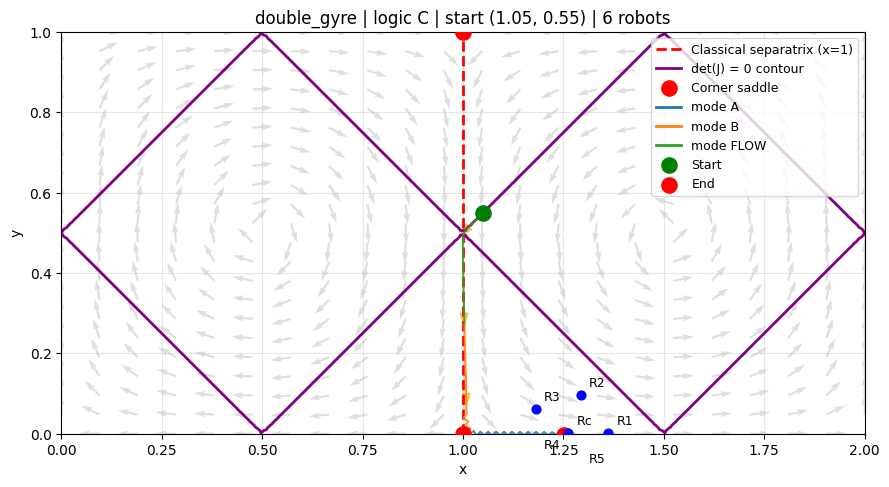

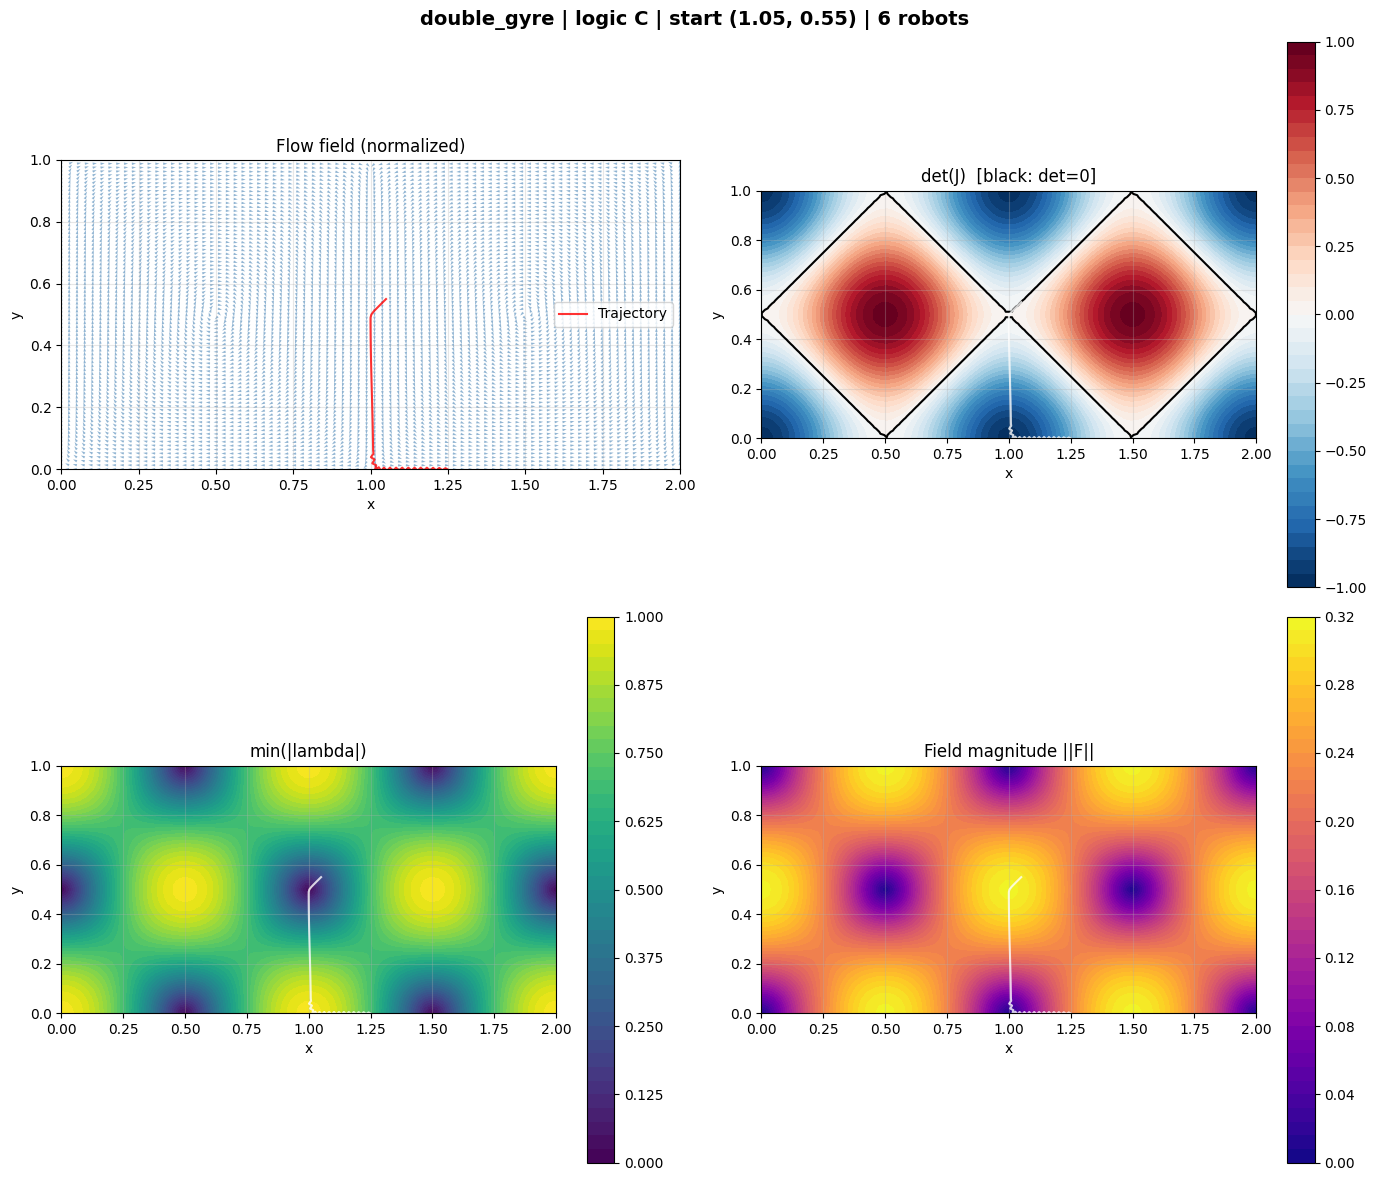

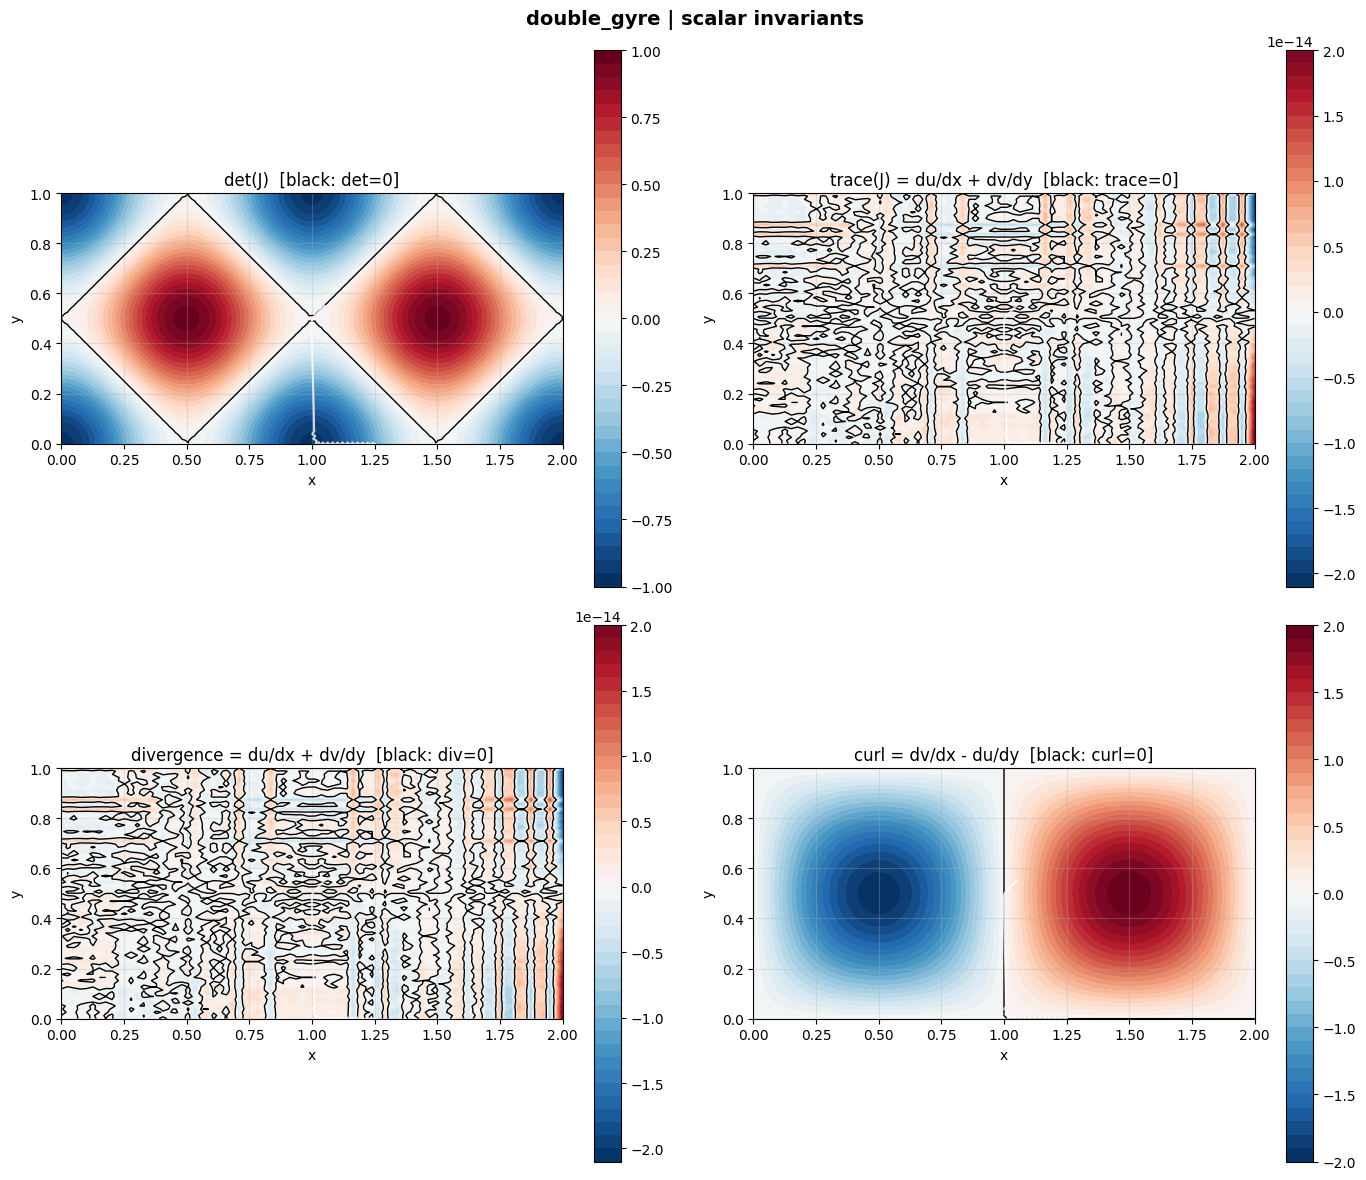

Logic:        C
Start:        (1.05, 0.55)
End:          (+1.262, +0.002)
det(J) end:   -0.450024
trace(J) end: +0.0000
Mode counts:  {'FLOW': 28, 'B': 28, 'A': 24}
eps_raw final: 4.572e-01   eps_dim final: 3.599e-02


In [172]:
from collections import Counter

# -------- EDIT THESE --------
field_type       = 'double_gyre'
logic            = 'C'            # 'A'/'B' = original steppers; 'C' = hybrid 3-mode
initial_pos      = (1.05, 0.55)    # slightly off the separatrix
n_iterations     = 80
formation_radius = 0.1    # ring radius of the pentagon (use 0.05-0.1 for double_gyre)
v_max            = 0.01   # AdaptiveEigenStepper saturation level (m/step)

# Hybrid stepper thresholds (used by logic C only)
EPS_RAW = 1e-3   # enter FLOW mode when |det(J)| < EPS_RAW
EPS_DIM = 0.025  # enter FLOW mode when |det(J)| / ||H_det||_F < EPS_DIM

# double_gyre parameters (ignored for other field types)
dg_A     = 0.1    # flow amplitude; typical 0.1
dg_eps   = 0.0    # boundary oscillation amplitude; 0 = steady, 0.1-0.25 = unsteady
dg_omega = 2*np.pi/10  # oscillation frequency (rad/step); period T = 2*pi/omega
dg_t     = 0.0    # time snapshot; only matters when dg_eps > 0
# ----------------------------

vf        = VectorField(field_type=field_type,
                        dg_A=dg_A, dg_eps=dg_eps, dg_omega=dg_omega, dg_t=dg_t)
formation = PentagonFormation(radius=formation_radius, base_angle=0.0)
estimator = QuadraticEstimator()

if logic == 'A':
    stepper = AdaptiveEigenStepper(v_max=v_max)
elif logic == 'B':
    stepper = AdaptiveEigenStepperAbs(v_max=v_max)
elif logic == 'C':
    stepper = LogicCStepper(v_max=v_max, eps_raw=EPS_RAW, eps_dim=EPS_DIM)
else:
    raise ValueError(f"Unknown logic: {logic!r}. Use 'A', 'B', or 'C'.")

centroid      = np.array(initial_pos, dtype=float)
centroid_hist = np.zeros((n_iterations, 2))
step_hist     = []
mode_hist     = []
eps_raw_hist  = []
eps_dim_hist  = []

for k in range(n_iterations):
    centroid_hist[k] = centroid

    robots  = formation.robot_positions(centroid)
    rel_pos = formation.relative_positions(centroid)

    readings = np.array([vf.evaluate(p[0], p[1]) for p in robots])  # (6, 2)
    theta_u  = estimator.fit(rel_pos, readings[:, 0])
    theta_v  = estimator.fit(rel_pos, readings[:, 1])

    grad_det = QuadraticEstimator.det_gradient(theta_u, theta_v)
    H_det    = QuadraticEstimator.det_hessian(theta_u, theta_v)

    if logic in ('A', 'B'):
        step = stepper.compute_step(grad_det, H_det)
        mode = logic
    else:
        step, mode = stepper.compute_step(theta_u, theta_v, grad_det, H_det)

    step_hist.append((centroid.copy(), step.copy()))
    mode_hist.append(mode)

    det_val = abs(QuadraticEstimator.det_value(theta_u, theta_v))
    H_norm  = max(np.linalg.norm(H_det, 'fro'), 1e-12)
    eps_raw_hist.append(det_val)
    eps_dim_hist.append(det_val / H_norm)

    centroid = centroid + step

# Plots
final_positions = formation.robot_positions(centroid)
title = f"{field_type} | logic {logic} | start {initial_pos} | 6 robots"

mh = mode_hist if logic == 'C' else None
_ = plot_trial(centroid_hist, step_hist, final_positions, vf, title=title, mode_hist=mh)
plt.show()

_ = plot_field_analysis(vf, centroid_hist, title=title)
plt.show()

_ = plot_field_invariants(vf, centroid_hist, title=f"{field_type} | scalar invariants")
plt.show()

# Summary
J_end = vf.jacobian_twosided(*centroid)
print(f"Logic:        {logic}")
print(f"Start:        {initial_pos}")
print(f"End:          ({centroid[0]:+.3f}, {centroid[1]:+.3f})")
print(f"det(J) end:   {np.linalg.det(J_end):+.6f}")
print(f"trace(J) end: {np.trace(J_end):+.4f}")
if logic == 'C':
    print(f"Mode counts:  {dict(Counter(mode_hist))}")
    print(f"eps_raw final: {eps_raw_hist[-1]:.3e}   eps_dim final: {eps_dim_hist[-1]:.3e}")

---

### Optional: det(J) heatmap

Useful when picking starting positions -- shows where det(J) is near zero.

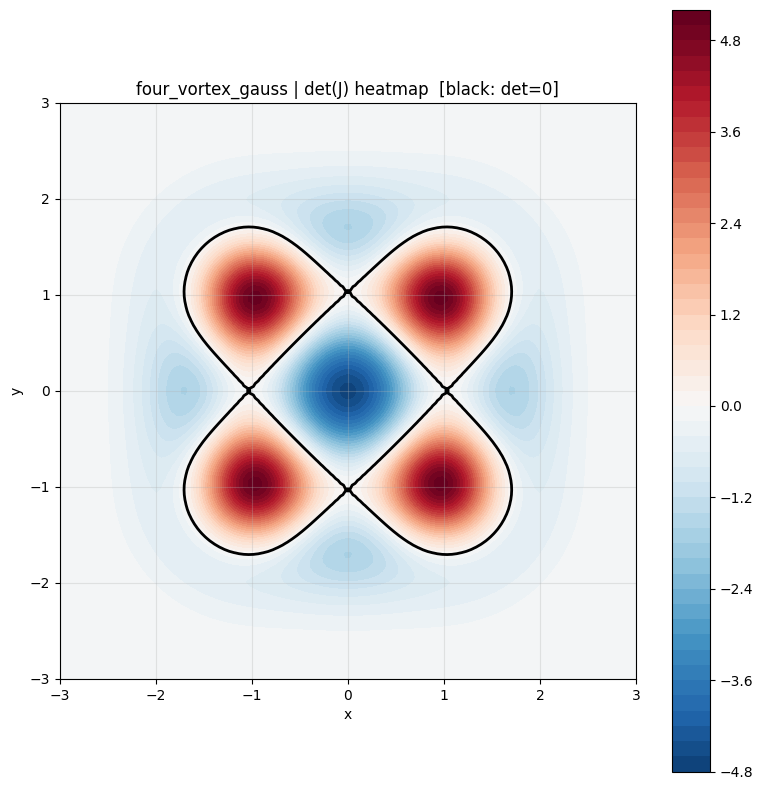

In [170]:
# Change field_type here independently if you want to explore a different field.
_vf_map = VectorField(field_type=field_type)
xlim_m, ylim_m = _field_limits(_vf_map)
res_m = 120
xs_m = np.linspace(*xlim_m, res_m)
ys_m = np.linspace(*ylim_m, res_m)
Xm, Ym = np.meshgrid(xs_m, ys_m)
Dm = np.zeros_like(Xm)
for i in range(res_m):
    for j in range(res_m):
        Dm[i, j] = np.linalg.det(_vf_map.jacobian_twosided(Xm[i, j], Ym[i, j]))

fig_m, ax_m = plt.subplots(figsize=(8, 8))
lim_dm = max(abs(Dm.min()), abs(Dm.max()))
cs_m = ax_m.contourf(Xm, Ym, Dm, levels=50, cmap='RdBu_r', vmin=-lim_dm, vmax=lim_dm)
ax_m.contour(Xm, Ym, Dm, levels=[0], colors='black', linewidths=2)
plt.colorbar(cs_m, ax=ax_m)
ax_m.set_xlim(xlim_m); ax_m.set_ylim(ylim_m)
ax_m.set_aspect('equal'); ax_m.grid(alpha=0.3)
ax_m.set_xlabel('x'); ax_m.set_ylabel('y')
ax_m.set_title(f"{field_type} | det(J) heatmap  [black: det=0]")
plt.tight_layout()
plt.show()